In [ ]:
annotations_dir = '/content/drive/MyDrive/VISDRONE/annotations'

In [ ]:
import pandas as pd

# Initialize lists to store parsed data
all_annotations = []

# Loop through all annotation files
for filename in annotation_files:
    filepath = os.path.join(annotations_dir, filename)
    with open(filepath, 'r') as f:
        for line in f:
            # Strip whitespace from the line
            stripped_line = line.strip()

            # Skip empty lines
            if not stripped_line:
                continue

            # Split the line by comma and filter out any empty strings that might result
            # from consecutive commas or trailing commas
            raw_parts = stripped_line.split(',')
            valid_parts_str = [p.strip() for p in raw_parts if p.strip()] # ensure part is not empty after stripping

            # Ensure there are enough elements to parse (at least 8 for VisDrone format)
            if len(valid_parts_str) < 8:
                print(f"Warning: Skipping malformed line in {filename}: '{stripped_line}' - not enough parts ({len(valid_parts_str)} found, 8 expected).")
                continue

            # Convert valid parts to integers
            parts = list(map(int, valid_parts_str))

            # According to VisDrone documentation, the format is:
            # <bbox_left>,<bbox_top>,<bbox_width>,<bbox_height>,<score>,<object_category>,<truncation>,<occlusion>
            # We are interested in bbox_width, bbox_height, and object_category
            bbox_left, bbox_top, bbox_width, bbox_height, score, object_category, truncation, occlusion = parts[:8]
            all_annotations.append({
                'width': bbox_width,
                'height': bbox_height,
                'category': object_category
            })

# Create a DataFrame from the collected annotations
annotations_df = pd.DataFrame(all_annotations)

print(f"Successfully parsed {len(annotations_df)} annotations from {len(annotation_files)} files.")
print("First 5 rows of the DataFrame:")
print(annotations_df.head())

Successfully parsed 353550 annotations from 6471 files.
First 5 rows of the DataFrame:
   width  height  category
0    273     116         0
1    265      70         0
2    119     128         0
3    209      78         0
4     74      33         4


In [ ]:
# Define the category mapping
category_mapping = {0: 'pedestrian', 1: 'people', 2: 'bicycle', 3: 'car', 4: 'van', 5: 'truck', 6: 'tricycle', 7: 'awning-tricycle', 8: 'bus', 9: 'motor', 10: 'others', 11: 'motorcycle'}

# Add a new column 'category_name' to annotations_df
annotations_df['category_name'] = annotations_df['category'].map(category_mapping)

print("DataFrame with 'category_name' column added:")
print(annotations_df.head())

DataFrame with 'category_name' column added:
   width  height  category category_name
0    273     116         0    pedestrian
1    265      70         0    pedestrian
2    119     128         0    pedestrian
3    209      78         0    pedestrian
4     74      33         4           van


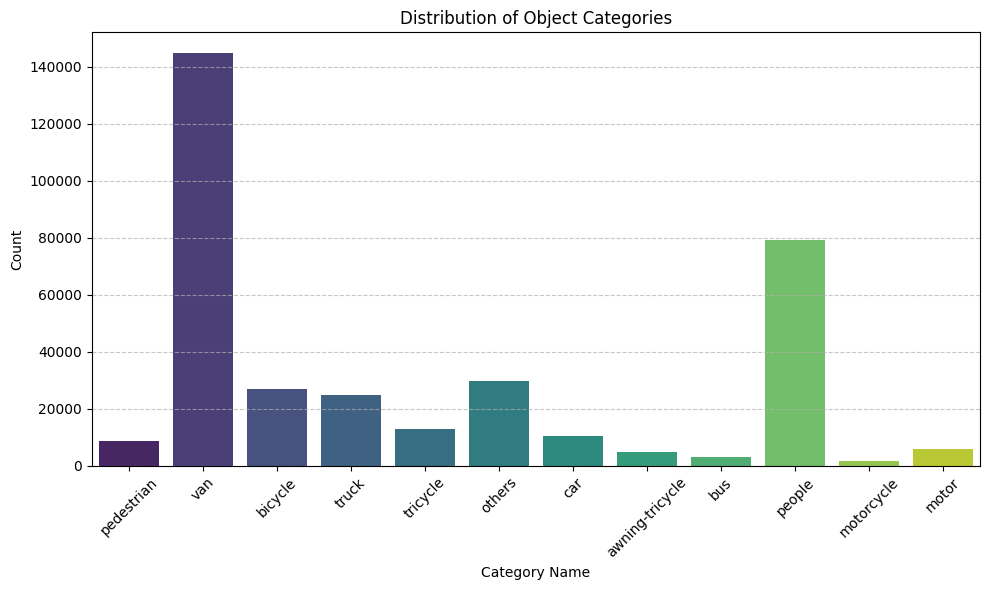

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=annotations_df, x='category_name', hue='category_name', palette='viridis', legend=False)
plt.title('Distribution of Object Categories')
plt.xlabel('Category Name')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

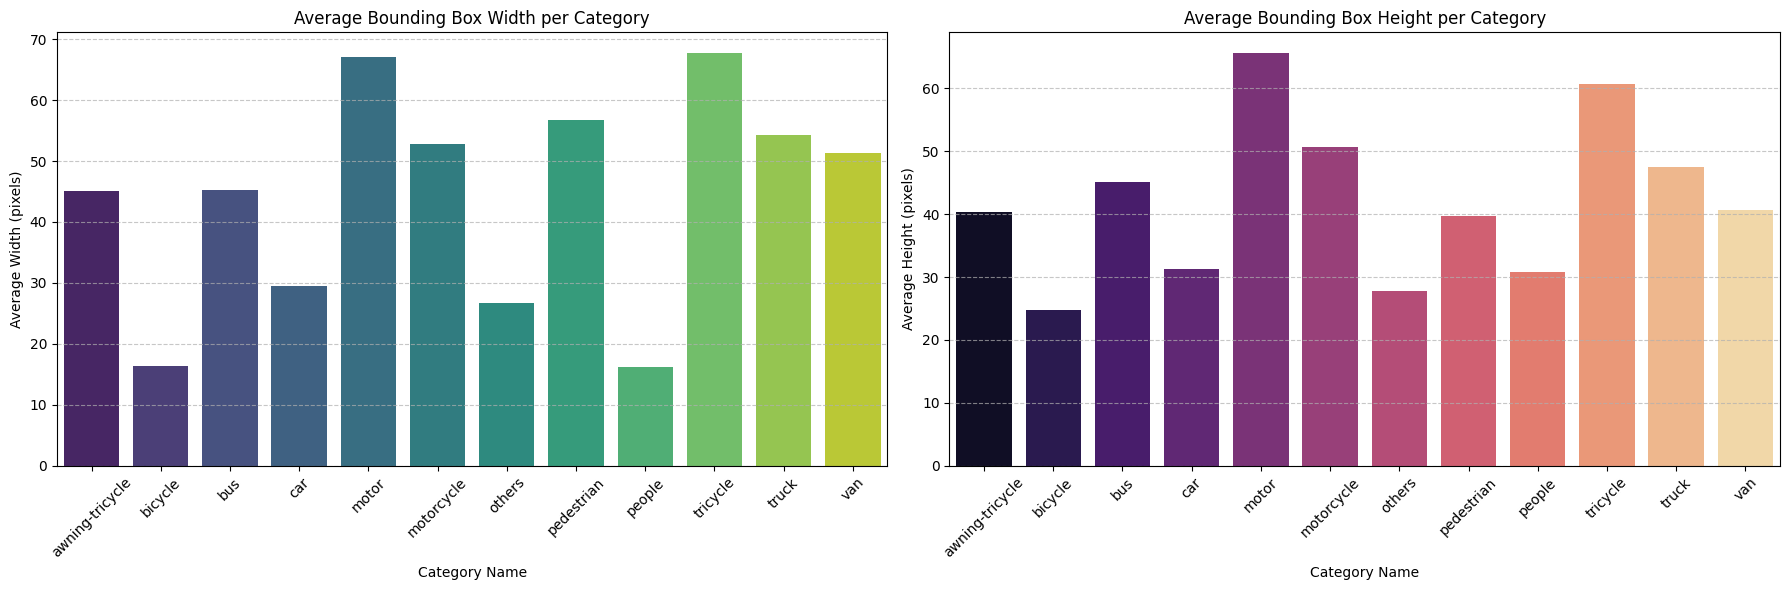

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average width and height per category
avg_dims_per_category = annotations_df.groupby('category_name')[['width', 'height']].mean().reset_index()

# Create subplots for average width and height
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)

# Plot average width
sns.barplot(ax=axes[0], x='category_name', y='width', data=avg_dims_per_category, palette='viridis', hue='category_name', legend=False)
axes[0].set_title('Average Bounding Box Width per Category')
axes[0].set_xlabel('Category Name')
axes[0].set_ylabel('Average Width (pixels)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot average height
sns.barplot(ax=axes[1], x='category_name', y='height', data=avg_dims_per_category, palette='magma', hue='category_name', legend=False)
axes[1].set_title('Average Bounding Box Height per Category')
axes[1].set_xlabel('Category Name')
axes[1].set_ylabel('Average Height (pixels)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [1]:
"""
VisDrone Object Detection Pipeline
===================================
A complete, modular pipeline covering:
  1. Dataset loading & preprocessing (VisDrone format)
  2. Data augmentation & transforms
  3. Model definition (ResNet-50 backbone → FPN neck → SSD heads)
  4. Anchor generation & box encoding/decoding
  5. Multi-task loss (Focal + Smooth-L1)
  6. Training loop with LR scheduling & gradient clipping
  7. COCO-style evaluation with pycocotools

Run:
  python visdrone_pipeline.py

Requirements:
  pip install torch torchvision pycocotools albumentations
"""

# =============================================================================
# SECTION 0: IMPORTS & GLOBAL CONFIG
# =============================================================================

import os
import json
import math
import time
import itertools
from pathlib import Path
from typing import List, Tuple, Dict, Optional

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
import torchvision.ops as tv_ops          # for nms, box_iou, etc.
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# ── Paths ─────────────────────────────────────────────────────────────────────
# Adjust these to wherever you downloaded the VisDrone subsets
# ROOT          = Path("./data/VisDrone")
ROOT          = Path("/content/drive/MyDrive/VISDRONE")
TRAIN_IMG_DIR = ROOT / "VisDrone2019-DET-train" / "images"
TRAIN_ANN_DIR = ROOT / "VisDrone2019-DET-train" / "annotations"
VAL_IMG_DIR   = ROOT / "VisDrone2019-DET-val"   / "images"
VAL_ANN_DIR   = ROOT / "VisDrone2019-DET-val"   / "annotations"

# ── Training hyper-parameters ─────────────────────────────────────────────────
CFG = {
    "img_size":        640,     # input resolution fed to the model
    "num_classes":     10,      # VisDrone has 10 object categories
    "batch_size":      8,
    "num_workers":     2,   # Colab recommends ≤ 2; 4 triggers DataLoader warning
    "epochs":          100,
    "lr":              1e-4,
    "weight_decay":    5e-4,
    "warmup_epochs":   3,
    "grad_clip":       10.0,    # max gradient norm — prevents exploding gradients
    # SSD / Anchor settings
    "anchor_sizes":    [32, 64, 128],   # FIX: exactly 3 sizes, one per FPN level (P3=32, P4=64, P5=128).
    #                               # 4 entries caused AnchorGenerator to create a phantom stride-64 level
    #                               # that the FPN never produces → anchor count (25,500) ≠ pred count (100,800).
    "anchor_ratios":   [0.5, 1.0, 2.0],
    # Loss weights
    "lambda_cls":      1.0,
    "lambda_reg":      1.0,
    # Matching
    "pos_iou_thresh":  0.5,     # IoU ≥ this → positive anchor
    "neg_iou_thresh":  0.4,     # IoU <  this → negative anchor (in between = ignored)
    # Inference
    "score_thresh":    0.05,
    "nms_thresh":      0.45,
    "max_dets":        500,     # VisDrone allows 500 detections per image
    "device":          "cuda" if torch.cuda.is_available() else "cpu",
    "checkpoint_dir":  "./checkpoints",
}

# ── VisDrone class mapping ────────────────────────────────────────────────────
# Category IDs in annotations are 1-indexed (0 = ignored region)
VISDRONE_CLASSES = {
    1: "pedestrian",   2: "person",       3: "bicycle",
    4: "car",          5: "van",          6: "truck",
    7: "tricycle",     8: "awning-tricycle", 9: "bus",
    10: "motor",
}


# =============================================================================
# SECTION 1: DATASET — loading VisDrone annotation files
# =============================================================================

class VisDroneDataset(Dataset):
    """
    Loads the VisDrone-DET subset (either train or val).

    VisDrone annotation format (one .txt per image, space-separated):
      bbox_left, bbox_top, bbox_width, bbox_height,
      score, object_category, truncation, occlusion

    We ignore:
      - category 0  (ignored region — not a real object)
      - score 0     (also indicates 'ignored')
    """

    def __init__(
        self,
        img_dir: Path,
        ann_dir: Path,
        transforms=None,
    ):
        self.img_dir    = Path(img_dir)
        self.ann_dir    = Path(ann_dir)
        self.transforms = transforms

        # Build a list of (image_path, annotation_path) pairs
        # We glob for all images and match each to its annotation file
        img_extensions = {".jpg", ".jpeg", ".png"}
        self.samples = []
        for img_path in sorted(self.img_dir.iterdir()):
            if img_path.suffix.lower() not in img_extensions:
                continue
            ann_path = self.ann_dir / (img_path.stem + ".txt")
            if ann_path.exists():
                self.samples.append((img_path, ann_path))

        print(f"[Dataset] Found {len(self.samples)} images in {img_dir}")

    def __len__(self) -> int:
        return len(self.samples)

    def _parse_annotation(self, ann_path: Path) -> Tuple[np.ndarray, np.ndarray]:
        """
        Returns:
          boxes  — (N, 4) float32 in [x1, y1, x2, y2] format  (absolute pixels)
          labels — (N,)   int64  in range [0, num_classes-1]
        """
        boxes, labels = [], []

        with open(ann_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split(",")
                if len(parts) < 6:
                    continue

                x, y, w, h     = (float(p) for p in parts[:4])
                score          = int(parts[4])
                category       = int(parts[5])

                # Skip 'ignored region' entries
                if category == 0 or score == 0:
                    continue

                # Degenerate boxes with zero area are useless for training
                if w <= 0 or h <= 0:
                    continue

                # Convert (x, y, w, h) → (x1, y1, x2, y2)
                boxes.append([x, y, x + w, y + h])
                # Shift label to 0-indexed: category 1 → class 0
                labels.append(category - 1)

        if len(boxes) == 0:
            return np.zeros((0, 4), dtype=np.float32), np.zeros((0,), dtype=np.int64)

        return np.array(boxes, dtype=np.float32), np.array(labels, dtype=np.int64)

    def __getitem__(self, idx: int) -> Dict:
        img_path, ann_path = self.samples[idx]

        # Load image as RGB (OpenCV reads BGR by default)
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        boxes, labels = self._parse_annotation(ann_path)

        # Apply transforms (Albumentations handles bbox transformations automatically)
        if self.transforms is not None:
            transformed = self.transforms(
                image=image,
                bboxes=boxes.tolist(),
                labels=labels.tolist(),
            )
            image  = transformed["image"]                                   # tensor [3, H, W]
            boxes  = np.array(transformed["bboxes"],  dtype=np.float32)     # (N, 4) pascal_voc
            labels = np.array(transformed["labels"],  dtype=np.int64)

        return {
            "image":    image,                                              # float tensor [3, H, W]
            "boxes":    torch.as_tensor(boxes,  dtype=torch.float32),       # (N, 4)
            "labels":   torch.as_tensor(labels, dtype=torch.int64),         # (N,)
            "img_path": str(img_path),
        }


def collate_fn(batch: List[Dict]) -> Dict:
    """
    Custom collate: images into a batch tensor,
    boxes/labels stay as a list because different images have different numbers of objects.
    """
    images  = torch.stack([b["image"]  for b in batch], dim=0)  # [B, 3, H, W]
    boxes   = [b["boxes"]  for b in batch]                       # list of (Ni, 4)
    labels  = [b["labels"] for b in batch]                       # list of (Ni,)
    paths   = [b["img_path"] for b in batch]
    return {"images": images, "boxes": boxes, "labels": labels, "paths": paths}


# =============================================================================
# SECTION 2: TRANSFORMS & AUGMENTATION
# =============================================================================

def build_transforms(img_size: int, mode: str = "train"):
    """
    Albumentations pipelines for train and val.

    Why Albumentations over torchvision transforms?
    Albumentations applies the SAME random transformation to both the image
    AND the bounding boxes atomically, which torchvision v1 transforms can't do cleanly.

    bbox_params tells Albumentations:
      - format='pascal_voc'  → expects [x1, y1, x2, y2] (absolute pixels)
      - min_visibility=0.2   → after a crop, discard boxes whose visible fraction < 20%
      - label_fields=['labels'] → 'labels' is the companion list to 'bboxes'
    """
    bbox_params = A.BboxParams(
        format="pascal_voc",
        min_visibility=0.2,
        label_fields=["labels"],
    )

    if mode == "train":
        return A.Compose([
            # ── Geometric augmentations ──────────────────────────────────────
            A.LongestMaxSize(max_size=img_size),        # resize while preserving aspect ratio

            # FIX 1: Albumentations ≥ 1.4 renamed `value` → `fill` in PadIfNeeded.
            # The old `value` keyword was used to set the constant fill color for
            # BORDER_CONSTANT padding. The argument was renamed to `fill` to match
            # the OpenCV / torchvision convention more closely.
            A.PadIfNeeded(
                min_height=img_size,
                min_width=img_size,
                border_mode=cv2.BORDER_CONSTANT,
                fill=0,                             # ← was `value=0` in older versions
            ),

            A.HorizontalFlip(p=0.5),

            # FIX 2: Albumentations ≥ 1.4 changed RandomSizedCrop's signature.
            # The old API took separate `height` and `width` scalars.
            # The new API takes a single `size` argument that MUST be a (h, w) tuple.
            # Passing an int (640) triggers a Pydantic ValidationError because
            # the schema now expects `tuple[int, int]`, not `int`.
            A.RandomSizedCrop(
                min_max_height=(int(img_size * 0.6), img_size),
                size=(img_size, img_size),          # ← was height=img_size, width=img_size
                p=0.3,
            ),

            A.ShiftScaleRotate(
                shift_limit=0.05,
                scale_limit=0.1,
                rotate_limit=5,                     # small rotation — drones are mostly level
                border_mode=cv2.BORDER_CONSTANT,
                fill=0,                             # ← same fix as PadIfNeeded above
                p=0.3,
            ),

            # ── Photometric augmentations ────────────────────────────────────
            A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05, p=0.5),
            A.GaussianBlur(blur_limit=3, p=0.2),    # simulate out-of-focus drone footage
            A.GaussNoise(p=0.2),

            # ── Normalization & tensor conversion ────────────────────────────
            # ImageNet mean/std because our backbone was pretrained on ImageNet
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),   # H×W×C uint8 → C×H×W float32, scaled to [0,1] BEFORE normalize
        ], bbox_params=bbox_params)

    else:   # val / test — no random ops, just resize + normalize
        return A.Compose([
            A.LongestMaxSize(max_size=img_size),
            A.PadIfNeeded(
                min_height=img_size,
                min_width=img_size,
                border_mode=cv2.BORDER_CONSTANT,
                fill=0,                             # ← same fix as train branch
            ),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ], bbox_params=bbox_params)


In [2]:

# =============================================================================
# SECTION 3: MODEL DEFINITION
# =============================================================================
#
# Architecture overview:
#
#   Image [3, H, W]
#       │
#   ┌───▼──────────────────────────────────────┐
#   │  BACKBONE: ResNet-50                     │
#   │  (pretrained on ImageNet)                │
#   │  We tap three intermediate feature maps: │
#   │    C3 = layer2 output  (stride 8,  C=512)│
#   │    C4 = layer3 output  (stride 16, C=1024│
#   │    C5 = layer4 output  (stride 32, C=2048│
#   └───┬───────────────┬───────────────┬──────┘
#       C3              C4              C5
#       │               │               │
#   ┌───▼───────────────▼───────────────▼──────┐
#   │  NECK: Feature Pyramid Network (FPN)     │
#   │  • Lateral 1×1 convs: project all to 256d│
#   │  • Top-down pathway: upsample & add      │
#   │  Produces P3, P4, P5 — all 256-channel   │
#   └───┬───────────────┬───────────────┬──────┘
#       P3              P4              P5
#       │               │               │
#   ┌───▼───────────────▼───────────────▼──────┐
#   │  HEAD: SSD-style prediction heads        │
#   │  Per FPN level, two parallel branches:   │
#   │    cls_head → class logits (per anchor)  │
#   │    reg_head → box deltas  (per anchor)   │
#   └──────────────────────────────────────────┘
#
# =============================================================================

FPN_OUT_CHANNELS = 256  # all FPN levels project to this width


class FPN(nn.Module):
    """
    Feature Pyramid Network neck.

    Takes C3, C4, C5 from the backbone and produces P3, P4, P5
    all with `out_channels` channels and aligned feature map sizes:
      P5 has spatial size of C5 (stride 32)
      P4 = upsample(P5) + lateral(C4)   (stride 16)
      P3 = upsample(P4) + lateral(C3)   (stride 8)

    The top-down information flow is what makes this powerful:
    P3 has both the fine spatial detail of C3 AND the rich semantics of C5.
    """

    def __init__(self, in_channels: List[int], out_channels: int):
        super().__init__()

        # Lateral 1×1 convs: channel-reduce each backbone level independently
        # "Lateral" because they run sideways, not up/down the pyramid
        self.lateral_convs = nn.ModuleList([
            nn.Conv2d(c, out_channels, kernel_size=1) for c in in_channels
        ])

        # 3×3 smoothing convs applied after adding the upsampled feature
        # This removes the aliasing / checkerboard artifacts that upsample creates
        self.smooth_convs = nn.ModuleList([
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
            for _ in in_channels
        ])

    def forward(self, features: List[torch.Tensor]) -> List[torch.Tensor]:
        # features = [C3, C4, C5]  (low → high, fine → coarse)
        # lateral projections — reduce channels but don't change spatial size
        laterals = [lat(f) for lat, f in zip(self.lateral_convs, features)]

        # Top-down pass: start from the deepest (coarsest) level and work up
        # For each level, upsample by 2 and add to the level below
        for i in range(len(laterals) - 2, -1, -1):   # e.g. i = 1, then i = 0
            # F.interpolate with nearest mode is fast and parameter-free
            upsampled = F.interpolate(
                laterals[i + 1],
                size=laterals[i].shape[-2:],
                mode="nearest",
            )
            laterals[i] = laterals[i] + upsampled

        # Apply smoothing convs to suppress the aliasing from upsampling
        pyramid = [smooth(lat) for smooth, lat in zip(self.smooth_convs, laterals)]
        return pyramid  # [P3, P4, P5]


class SSDHead(nn.Module):
    """
    Shared-weight SSD-style prediction head.

    "Shared-weight" means the SAME convolutional weights are applied
    to each FPN level — they share parameters. This works because all
    FPN levels have the same `in_channels` after the FPN neck,
    and it greatly reduces the total parameter count.

    For each spatial location on the feature map:
      - cls_head predicts `num_anchors × num_classes` logits
      - reg_head predicts `num_anchors × 4` box deltas (tx, ty, tw, th)

    The box encoding follows the SSD convention:
      tx = (cx_gt - cx_anchor) / anchor_w
      ty = (cy_gt - cy_anchor) / anchor_h
      tw = log(w_gt / anchor_w)
      th = log(h_gt / anchor_h)
    """

    def __init__(self, in_channels: int, num_anchors: int, num_classes: int):
        super().__init__()
        self.num_anchors = num_anchors
        self.num_classes = num_classes

        # Two hidden conv layers before prediction — this is the "head tower"
        self.tower = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, in_channels, 3, padding=1),
            nn.ReLU(inplace=True),
        )

        # Classification branch: for each anchor, predict logits for each class
        # Output shape per level: [B, num_anchors × num_classes, H, W]
        self.cls_head = nn.Conv2d(in_channels, num_anchors * num_classes, kernel_size=3, padding=1)

        # Regression branch: for each anchor, predict 4 offsets
        # Output shape per level: [B, num_anchors × 4, H, W]
        self.reg_head = nn.Conv2d(in_channels, num_anchors * 4, kernel_size=3, padding=1)

        # Initialize classification bias so initial class probability is ~0.01
        # This trick (from RetinaNet) prevents the huge foreground/background
        # imbalance from blowing up the loss at the very start of training
        prior_prob = 0.01
        bias_value = -math.log((1 - prior_prob) / prior_prob)
        nn.init.constant_(self.cls_head.bias, bias_value)

    def forward(self, features: List[torch.Tensor]):
        """
        features: list of [B, C, Hi, Wi] tensors, one per FPN level.
        Returns:
          cls_preds: [B, total_anchors, num_classes]
          reg_preds: [B, total_anchors, 4]
        """
        cls_preds_all, reg_preds_all = [], []

        for feat in features:
            feat = self.tower(feat)
            B    = feat.shape[0]

            cls_pred = self.cls_head(feat)      # [B, A×C, H, W]
            reg_pred = self.reg_head(feat)      # [B, A×4, H, W]

            # Reshape so that we get one row per (spatial location × anchor)
            # [B, A×C, H, W] → [B, H×W×A, C]
            cls_pred = cls_pred.permute(0, 2, 3, 1).reshape(B, -1, self.num_classes)
            reg_pred = reg_pred.permute(0, 2, 3, 1).reshape(B, -1, 4)

            cls_preds_all.append(cls_pred)
            reg_preds_all.append(reg_pred)

        # Concatenate across all FPN levels → one big prediction tensor per image
        cls_preds = torch.cat(cls_preds_all, dim=1)   # [B, total_anchors, C]
        reg_preds = torch.cat(reg_preds_all, dim=1)   # [B, total_anchors, 4]
        return cls_preds, reg_preds

class ResNetFPNSSD(nn.Module):
    """
    Full detector: ResNet‑18 backbone + FPN neck + SSD prediction heads.
    The backbone can be frozen by calling `freeze_backbone()`.
    """

    def __init__(self, num_classes: int, anchor_sizes: List[int], anchor_ratios: List[float]):
        super().__init__()
        self.num_classes   = num_classes
        self.anchor_sizes  = anchor_sizes
        self.anchor_ratios = anchor_ratios
        self.num_anchors   = len(anchor_ratios)

        # ── Backbone: ResNet‑18 pretrained on ImageNet ────────────
        resnet = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)

        # Separate backbone components for fine‑grained control
        self.backbone_stem   = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.backbone_layer1 = resnet.layer1   # stride 4,  channels = 64
        self.backbone_layer2 = resnet.layer2   # stride 8,  channels = 128  → C3
        self.backbone_layer3 = resnet.layer3   # stride 16, channels = 256  → C4
        self.backbone_layer4 = resnet.layer4   # stride 32, channels = 512  → C5

        # ── Neck: FPN ────────────────────────────────────────
        self.fpn = FPN(
            in_channels=[128, 256, 512],   # C3, C4, C5 for ResNet‑18
            out_channels=FPN_OUT_CHANNELS,
        )

        # ── Head: shared‑weight SSD ────────────────────────────────
        self.head = SSDHead(
            in_channels=FPN_OUT_CHANNELS,
            num_anchors=self.num_anchors,
            num_classes=num_classes,
        )

    def freeze_backbone(self) -> None:
        """
        Freeze all backbone parameters (stem + layers 1‑4).
        Gradients will not be computed for these parts during training.
        """
        backbone_modules = [
            self.backbone_stem,
            self.backbone_layer1,
            self.backbone_layer2,
            self.backbone_layer3,
            self.backbone_layer4,
        ]
        for module in backbone_modules:
            for param in module.parameters():
                param.requires_grad = False

    def train(self, mode: bool = True) -> "ResNetFPNSSD":
        """
        Override `train()` to keep frozen batch‑norm layers in evaluation mode.
        This is the recommended behaviour when backbone weights are frozen.
        """
        super().train(mode)
        if mode:
            # If the backbone is frozen, put its BN layers in eval mode
            # to prevent updating running statistics.
            self._set_bn_eval_for_frozen_backbone()
        return self

    def _set_bn_eval_for_frozen_backbone(self) -> None:
        """Set batch‑norm layers inside the frozen backbone to eval mode."""
        backbone_modules = [
            self.backbone_stem,
            self.backbone_layer1,
            self.backbone_layer2,
            self.backbone_layer3,
            self.backbone_layer4,
        ]
        for module in backbone_modules:
            for m in module.modules():
                if isinstance(m, nn.BatchNorm2d):
                    m.eval()

    def forward(self, images: torch.Tensor):
        """
        images: [B, 3, H, W]
        Returns:
          cls_preds: [B, total_anchors, num_classes]
          reg_preds: [B, total_anchors, 4]
        """
        x  = self.backbone_stem(images)
        x  = self.backbone_layer1(x)
        C3 = self.backbone_layer2(x)    # stride 8
        C4 = self.backbone_layer3(C3)   # stride 16
        C5 = self.backbone_layer4(C4)   # stride 32

        P3, P4, P5 = self.fpn([C3, C4, C5])
        cls_preds, reg_preds = self.head([P3, P4, P5])
        return cls_preds, reg_preds

In [3]:

# =============================================================================
# SECTION 4: ANCHOR GENERATION
# =============================================================================

class AnchorGenerator:
    """
    Generates a fixed grid of anchor boxes for each FPN level.

    For each level with stride S and anchor size A:
      For each spatial location (x_center, y_center) on the feature grid:
        For each aspect ratio r in [0.5, 1.0, 2.0]:
          anchor_w = A × √r
          anchor_h = A / √r
          Create anchor: (x_center, y_center, anchor_w, anchor_h)

    The anchors are generated ONCE at startup and reused every forward pass.
    They live in (cx, cy, w, h) format (center format).
    """

    def __init__(self, img_size: int, anchor_sizes: List[int], anchor_ratios: List[float]):
        self.img_size     = img_size
        self.anchor_sizes = anchor_sizes
        self.anchor_ratios = anchor_ratios
        # FPN strides: P3=8, P4=16, P5=32
        # Each stride corresponds to one entry in anchor_sizes
        self.strides      = [8, 16, 32, 64][:len(anchor_sizes)]

    @torch.no_grad()
    def generate(self, device: torch.device) -> torch.Tensor:
        """
        Returns all anchors as a [total_anchors, 4] tensor in (cx, cy, w, h) format.
        """
        all_anchors = []
        for stride, size in zip(self.strides, self.anchor_sizes):
            feat_h = feat_w = self.img_size // stride  # number of grid cells

            # Create all (cx, cy) grid centers in pixel coordinates
            # e.g. for stride=8 and img_size=640: centers at 4, 12, 20, ..., 636
            cx = (torch.arange(feat_w, device=device).float() + 0.5) * stride
            cy = (torch.arange(feat_h, device=device).float() + 0.5) * stride
            cy, cx = torch.meshgrid(cy, cx, indexing="ij")  # both [feat_h, feat_w]
            cx = cx.reshape(-1)  # [feat_h × feat_w]
            cy = cy.reshape(-1)

            # For each grid location, create anchors for all aspect ratios
            anchors_per_level = []
            for ratio in self.anchor_ratios:
                w = size * math.sqrt(ratio)   # wider  for ratio > 1
                h = size / math.sqrt(ratio)   # taller for ratio < 1
                # stack shape: [feat_h×feat_w, 4]
                anchors_per_level.append(
                    torch.stack([cx, cy,
                                 torch.full_like(cx, w),
                                 torch.full_like(cy, h)], dim=1)
                )
            all_anchors.append(torch.cat(anchors_per_level, dim=0))

        return torch.cat(all_anchors, dim=0)   # [total_anchors, 4], format: (cx, cy, w, h)


def cxcywh_to_xyxy(boxes: torch.Tensor) -> torch.Tensor:
    """(cx, cy, w, h) → (x1, y1, x2, y2)"""
    cx, cy, w, h = boxes.unbind(dim=-1)
    return torch.stack([cx - w/2, cy - h/2, cx + w/2, cy + h/2], dim=-1)

def xyxy_to_cxcywh(boxes: torch.Tensor) -> torch.Tensor:
    """(x1, y1, x2, y2) → (cx, cy, w, h)"""
    x1, y1, x2, y2 = boxes.unbind(dim=-1)
    return torch.stack([(x1+x2)/2, (y1+y2)/2, x2-x1, y2-y1], dim=-1)

def encode_boxes(gt_boxes_cxcywh: torch.Tensor, anchors_cxcywh: torch.Tensor) -> torch.Tensor:
    """
    Encode ground-truth boxes relative to anchors (SSD/Faster-RCNN convention).
    The model predicts these delta values, NOT raw pixel coordinates.

    tx = (cx_gt - cx_a) / w_a        ← offset in anchor widths
    ty = (cy_gt - cy_a) / h_a        ← offset in anchor heights
    tw = log(w_gt / w_a)             ← log-space scale change
    th = log(h_gt / h_a)
    """
    cx_a, cy_a, w_a, h_a = anchors_cxcywh.unbind(-1)
    cx_g, cy_g, w_g, h_g = gt_boxes_cxcywh.unbind(-1)

    tx = (cx_g - cx_a) / w_a
    ty = (cy_g - cy_a) / h_a
    tw = torch.log(w_g / w_a)
    th = torch.log(h_g / h_a)
    return torch.stack([tx, ty, tw, th], dim=-1)

def decode_boxes(reg_preds: torch.Tensor, anchors_cxcywh: torch.Tensor) -> torch.Tensor:
    """
    Inverse of encode_boxes: convert model deltas back to absolute (x1,y1,x2,y2).
    Called at inference time.
    """
    cx_a, cy_a, w_a, h_a = anchors_cxcywh.unbind(-1)
    tx, ty, tw, th        = reg_preds.unbind(-1)

    cx = tx * w_a + cx_a
    cy = ty * h_a + cy_a
    w  = torch.exp(tw) * w_a
    h  = torch.exp(th) * h_a
    return cxcywh_to_xyxy(torch.stack([cx, cy, w, h], dim=-1))


In [4]:


# =============================================================================
# SECTION 5: LOSS FUNCTION
# =============================================================================

class DetectionLoss(nn.Module):
    """
    Two-part multi-task loss for object detection:

    1. CLASSIFICATION LOSS — Focal Loss
       Why not cross-entropy? In detection, vastly more anchors are background
       than foreground (e.g. 10,000 anchors vs 50 objects → 200:1 imbalance).
       Standard CE gives equal weight to all negatives, so the gradient is
       completely dominated by easy background examples. The model learns
       "everything is background" and gets stuck.

       Focal Loss adds a modulating factor (1 - p_t)^γ that down-weights
       EASY examples and focuses training on HARD, misclassified ones.
         FL(p_t) = -(1 - p_t)^γ × log(p_t)
       γ=2 (the default) reduces loss from easy examples by ~100×.

    2. REGRESSION LOSS — Smooth L1 (Huber loss)
       For box coordinate regression, L2 loss is sensitive to outliers
       (a single bad box prediction explodes the gradient). L1 is more
       robust but has a discontinuous gradient at zero. Smooth L1 combines:
         |x| < β → 0.5 x²/β   (L2 near zero, smooth gradient)
         |x| ≥ β → |x| - 0.5β (L1 far from zero, bounded gradient)
    """

    def __init__(
        self,
        num_classes: int,
        pos_iou_thresh: float = 0.5,
        neg_iou_thresh: float = 0.4,
        focal_gamma: float = 2.0,
        focal_alpha: float = 0.25,
    ):
        super().__init__()
        self.num_classes    = num_classes
        self.pos_iou_thresh = pos_iou_thresh
        self.neg_iou_thresh = neg_iou_thresh
        self.focal_gamma    = focal_gamma
        self.focal_alpha    = focal_alpha

    def _focal_loss(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        targets: 0 = background, 1..C = foreground class labels (one-hot expanded inside)
        """
        # Convert logits to probabilities per class
        probs     = torch.sigmoid(logits)   # [N, C] — one probability per class
        # Binary cross-entropy without reduction
        bce_loss  = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        # The modulating factor: (1-p)^γ for foreground, p^γ for background
        p_t       = probs * targets + (1 - probs) * (1 - targets)
        focal_w   = self.focal_alpha * targets + (1 - self.focal_alpha) * (1 - targets)
        focal_w   = focal_w * (1 - p_t) ** self.focal_gamma
        return (focal_w * bce_loss).sum()

    def forward(
        self,
        cls_preds:  torch.Tensor,      # [B, A, C]
        reg_preds:  torch.Tensor,      # [B, A, 4]
        anchors:    torch.Tensor,      # [A, 4] in (cx, cy, w, h) format
        gt_boxes:   List[torch.Tensor],   # list of [Ni, 4] per image, xyxy
        gt_labels:  List[torch.Tensor],   # list of [Ni]    per image
    ) -> Tuple[torch.Tensor, torch.Tensor]:

        B       = cls_preds.shape[0]
        anchors_xyxy = cxcywh_to_xyxy(anchors)   # convert to xyxy for IoU computation

        cls_loss_total = torch.tensor(0.0, device=cls_preds.device)
        reg_loss_total = torch.tensor(0.0, device=reg_preds.device)
        num_pos        = 0

        for i in range(B):
            gt_boxes_i  = gt_boxes[i].to(cls_preds.device)   # [Ni, 4]
            gt_labels_i = gt_labels[i].to(cls_preds.device)  # [Ni]

            if gt_boxes_i.shape[0] == 0:
                # No GT objects: all anchors are background, no regression loss
                cls_targets = torch.zeros(cls_preds.shape[1], self.num_classes, device=cls_preds.device)
                cls_loss_total = cls_loss_total + self._focal_loss(cls_preds[i], cls_targets)
                continue

            # ── Anchor matching: assign each anchor to its best GT box ───────
            # tv_ops.box_iou computes the full IoU matrix [num_anchors × num_gt]
            iou_matrix = tv_ops.box_iou(anchors_xyxy, gt_boxes_i)   # [A, Ni]
            best_iou, best_gt_idx = iou_matrix.max(dim=1)            # [A] each

            # Positive anchors: IoU ≥ pos_thresh  (assigned to a GT box)
            # Ignored anchors:  neg_thresh ≤ IoU < pos_thresh  (ambiguous, skip)
            # Negative anchors: IoU < neg_thresh  (confidently background)
            pos_mask  = best_iou >= self.pos_iou_thresh   # [A] bool
            neg_mask  = best_iou < self.neg_iou_thresh
            # Ignored = neither pos nor neg → excluded from loss

            # ── Classification targets ───────────────────────────────────────
            # Build a multi-label soft target tensor [A, C] where
            # row i is one-hot for the class of the assigned GT box,
            # or all-zeros for background
            cls_targets = torch.zeros(cls_preds.shape[1], self.num_classes, device=cls_preds.device)
            pos_indices = pos_mask.nonzero(as_tuple=False).squeeze(1)
            if pos_indices.numel() > 0:
                # For each positive anchor, set its corresponding class bit to 1
                assigned_labels = gt_labels_i[best_gt_idx[pos_indices]]
                cls_targets[pos_indices, assigned_labels] = 1.0

            # Compute focal loss only on non-ignored anchors
            valid_mask = pos_mask | neg_mask
            cls_loss_total = cls_loss_total + self._focal_loss(
                cls_preds[i][valid_mask],
                cls_targets[valid_mask],
            )

            # ── Regression targets ───────────────────────────────────────────
            # Only positive anchors contribute to regression loss.
            # We encode the matched GT box relative to the anchor.
            if pos_indices.numel() > 0:
                matched_gt   = gt_boxes_i[best_gt_idx[pos_indices]]          # [P, 4] xyxy
                matched_anch = anchors[pos_indices]                           # [P, 4] cxcywh
                matched_gt_cxcywh = xyxy_to_cxcywh(matched_gt)
                reg_targets   = encode_boxes(matched_gt_cxcywh, matched_anch)  # [P, 4]

                reg_loss_total = reg_loss_total + F.smooth_l1_loss(
                    reg_preds[i][pos_indices],
                    reg_targets,
                    reduction="sum",
                    beta=1.0,
                )
                num_pos += pos_indices.numel()

        # Normalize by total number of positive anchors across the batch
        # This makes the loss scale invariant to batch size and scene density
        num_pos = max(num_pos, 1)
        cls_loss = cls_loss_total / num_pos
        reg_loss = reg_loss_total / num_pos
        return cls_loss, reg_loss


In [5]:
!pip install torchinfo
import torchinfo

# Instantiate the model using the global CFG
device = torch.device(CFG["device"])
model_summary = ResNetFPNSSD(
    num_classes=CFG["num_classes"],
    anchor_sizes=CFG["anchor_sizes"],
    anchor_ratios=CFG["anchor_ratios"],
).to(device)

model_summary.freeze_backbone()

# Print the model summary
torchinfo.summary(model_summary, input_size=(1, 3, CFG["img_size"], CFG["img_size"]))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


Layer (type:depth-idx)                   Output Shape              Param #
ResNetFPNSSD                             [1, 25200, 10]            --
├─Sequential: 1-1                        [1, 64, 160, 160]         --
│    └─Conv2d: 2-1                       [1, 64, 320, 320]         (9,408)
│    └─BatchNorm2d: 2-2                  [1, 64, 320, 320]         (128)
│    └─ReLU: 2-3                         [1, 64, 320, 320]         --
│    └─MaxPool2d: 2-4                    [1, 64, 160, 160]         --
├─Sequential: 1-2                        [1, 64, 160, 160]         --
│    └─BasicBlock: 2-5                   [1, 64, 160, 160]         --
│    │    └─Conv2d: 3-1                  [1, 64, 160, 160]         (36,864)
│    │    └─BatchNorm2d: 3-2             [1, 64, 160, 160]         (128)
│    │    └─ReLU: 3-3                    [1, 64, 160, 160]         --
│    │    └─Conv2d: 3-4                  [1, 64, 160, 160]         (36,864)
│    │    └─BatchNorm2d: 3-5             [1, 64, 160, 160]    

In [6]:
total = sum(p.numel() for p in model_summary.parameters())
trainable = sum(p.numel() for p in model_summary.parameters() if p.requires_grad)
frozen = total - trainable
print(f"total: {total}, trainable: {trainable}, frozen: {frozen})")


total: 14453866, trainable: 3277354, frozen: 11176512)


In [7]:


# =============================================================================
# SECTION 6: POST-PROCESSING (for inference)
# =============================================================================

@torch.no_grad()
def postprocess(
    cls_preds:   torch.Tensor,    # [A, num_classes] for a SINGLE image
    reg_preds:   torch.Tensor,    # [A, 4]
    anchors:     torch.Tensor,    # [A, 4] cxcywh
    img_size:    int,
    score_thresh: float = 0.05,
    nms_thresh:   float = 0.45,
    max_dets:     int   = 500,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Convert raw model outputs to final detections for one image.

    Returns:
      boxes  — [K, 4] float32, absolute pixel coords (x1, y1, x2, y2)
      scores — [K]    float32
      labels — [K]    int64    (0-indexed class)
    """
    # Decode regression deltas → absolute bounding boxes
    boxes = decode_boxes(reg_preds, anchors)                     # [A, 4] xyxy
    boxes = boxes.clamp(min=0, max=img_size)                     # clip to image boundary

    # Sigmoid → class probabilities (we trained with binary cross-entropy per class)
    scores = torch.sigmoid(cls_preds)                            # [A, C]

    # Flatten: for each anchor × class combination, get a score
    num_classes    = scores.shape[1]
    all_boxes      = boxes.unsqueeze(1).expand(-1, num_classes, -1).reshape(-1, 4)
    all_scores     = scores.reshape(-1)
    all_labels     = torch.arange(num_classes, device=scores.device).unsqueeze(0) \
                         .expand(scores.shape[0], -1).reshape(-1)

    # Pre-NMS threshold: discard the overwhelming majority of low-score anchors
    keep = all_scores > score_thresh
    all_boxes, all_scores, all_labels = all_boxes[keep], all_scores[keep], all_labels[keep]

    if all_boxes.numel() == 0:
        return (torch.zeros((0, 4)), torch.zeros(0), torch.zeros(0, dtype=torch.long))

    # Batched NMS: runs NMS independently per class
    # tv_ops.batched_nms handles the per-class offset trick internally
    keep_idx = tv_ops.batched_nms(all_boxes, all_scores, all_labels, nms_thresh)
    keep_idx = keep_idx[:max_dets]

    return all_boxes[keep_idx], all_scores[keep_idx], all_labels[keep_idx]


In [8]:
# =============================================================================
# SECTION 7: TRAINING LOOP
# =============================================================================

def build_optimizer_and_scheduler(model: nn.Module, cfg: dict, steps_per_epoch: int):
    """
    AdamW optimizer with cosine annealing and linear warmup.

    Why AdamW over SGD?
    For detection models, AdamW is more robust to hyper-parameter choice.
    SGD with momentum can reach higher peak accuracy but requires very careful
    LR tuning. For an assignment / first pass, AdamW is the safer choice.
    """
    # Separate parameters: backbone (pretrained) gets a LOWER learning rate
    # because it's already initialized well — we just want to fine-tune it gently.
    # The neck and head are randomly initialized so they need the full LR.
    backbone_params = list(model.backbone_stem.parameters()) + \
                      list(model.backbone_layer1.parameters()) + \
                      list(model.backbone_layer2.parameters()) + \
                      list(model.backbone_layer3.parameters()) + \
                      list(model.backbone_layer4.parameters())
    other_params    = list(model.fpn.parameters()) + list(model.head.parameters())

    optimizer = torch.optim.AdamW([
        {"params": backbone_params, "lr": cfg["lr"] * 0.1},  # backbone: 10× smaller LR
        {"params": other_params,    "lr": cfg["lr"]},
    ], weight_decay=cfg["weight_decay"])

    # Cosine annealing LR schedule: smoothly decays LR to near-zero by the last epoch
    # This avoids oscillating around the minimum at the end of training
    total_steps   = cfg["epochs"] * steps_per_epoch
    warmup_steps  = cfg["warmup_epochs"] * steps_per_epoch

    def lr_lambda(step):
        if step < warmup_steps:
            # Linear warmup: LR ramps from 0 → 1.0× over warmup_steps
            return step / max(1, warmup_steps)
        # Cosine decay from 1.0 → 0.0 over the remaining steps
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    return optimizer, scheduler


def train_one_epoch(
    model:       nn.Module,
    loader:      DataLoader,
    optimizer:   torch.optim.Optimizer,
    scheduler,
    loss_fn:     DetectionLoss,
    anchors:     torch.Tensor,
    cfg:         dict,
    epoch:       int,
) -> float:
    """
    Runs a single training epoch. Returns the average total loss.
    """
    model.train()
    device      = cfg["device"]
    total_loss  = 0.0
    t_start     = time.time()

    for step, batch in enumerate(loader):
        images    = batch["images"].to(device)     # [B, 3, H, W]
        gt_boxes  = batch["boxes"]                 # list of tensors
        gt_labels = batch["labels"]

        # ── Forward pass ────────────────────────────────────────────────────
        cls_preds, reg_preds = model(images)       # [B, A, C], [B, A, 4]

        # ── Compute loss ─────────────────────────────────────────────────────
        cls_loss, reg_loss = loss_fn(
            cls_preds, reg_preds,
            anchors.to(device),
            gt_boxes, gt_labels,
        )
        loss = cfg["lambda_cls"] * cls_loss + cfg["lambda_reg"] * reg_loss

        # ── Backward pass ────────────────────────────────────────────────────
        optimizer.zero_grad(set_to_none=True)  # set_to_none=True is faster than zero_grad()
        loss.backward()

        # Gradient clipping: if gradient norm exceeds `grad_clip`, rescale it.
        # This prevents gradient explosions especially at the start of training.
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])

        optimizer.step()
        scheduler.step()     # step-level (not epoch-level) LR update

        total_loss += loss.item()

        if step % 50 == 0:
            elapsed = time.time() - t_start
            lr      = scheduler.get_last_lr()[0]
            print(
                f"  [Epoch {epoch:3d} | Step {step:4d}/{len(loader)}] "
                f"cls={cls_loss.item():.4f}  reg={reg_loss.item():.4f}  "
                f"total={loss.item():.4f}  lr={lr:.2e}  t={elapsed:.0f}s"
            )

    return total_loss / len(loader)

In [ ]:

# =============================================================================
# SECTION 8: COCO-FORMAT EVALUATION
# =============================================================================

def build_coco_gt(dataset: VisDroneDataset) -> dict:
    """
    Build a COCO-format ground-truth dictionary from the VisDrone dataset.
    pycocotools expects this exact JSON structure.
    """
    coco_gt = {
        "images":      [],
        "annotations": [],
        "categories":  [{"id": i, "name": v} for i, v in VISDRONE_CLASSES.items()],
    }
    ann_id = 0
    for img_id, (img_path, ann_path) in enumerate(dataset.samples):
        # Read image size (without loading full image — much faster)
        img = cv2.imread(str(img_path))
        h, w = img.shape[:2]
        coco_gt["images"].append({
            "id": img_id,
            "file_name": img_path.name,
            "height": h,
            "width": w,
        })
        boxes, labels = dataset._parse_annotation(ann_path)
        for box, label in zip(boxes, labels):
            x1, y1, x2, y2 = box.tolist()
            coco_gt["annotations"].append({
                "id":          ann_id,
                "image_id":    img_id,
                "category_id": int(label) + 1,   # COCO is 1-indexed
                "bbox":        [x1, y1, x2 - x1, y2 - y1],  # COCO uses xywh
                "area":        (x2 - x1) * (y2 - y1),
                "iscrowd":     0,
            })
            ann_id += 1
    return coco_gt


@torch.no_grad()
def evaluate(
    model:     nn.Module,
    dataset:   VisDroneDataset,
    loader:    DataLoader,
    anchors:   torch.Tensor,
    cfg:       dict,
) -> float:
    """
    Runs inference on the val set, formats results for COCO eval,
    and prints the standard COCO detection metrics (AP, AR, etc.).

    Returns: mAP@0.50:0.95
    """
    model.eval()
    device       = cfg["device"]
    coco_results = []    # list of COCO-format result dicts

    # Build the ground-truth COCO object (only once)
    print("[Eval] Building COCO ground-truth annotations...")
    coco_gt_dict = build_coco_gt(dataset)
    coco_gt_obj  = COCO()
    coco_gt_obj.dataset = coco_gt_dict
    coco_gt_obj.createIndex()

    # Map image path → COCO image_id  (needed to attach predictions to the right image)
    path_to_id = {str(p): i for i, (p, _) in enumerate(dataset.samples)}

    print("[Eval] Running inference...")
    for batch in loader:
        images = batch["images"].to(device)
        paths  = batch["paths"]

        cls_preds, reg_preds = model(images)   # [B, A, C], [B, A, 4]

        for j in range(images.shape[0]):
            boxes, scores, labels = postprocess(
                cls_preds[j], reg_preds[j], anchors.to(device),
                img_size=cfg["img_size"],
                score_thresh=cfg["score_thresh"],
                nms_thresh=cfg["nms_thresh"],
                max_dets=cfg["max_dets"],
            )

            img_id = path_to_id[paths[j]]
            for box, score, label in zip(boxes.tolist(), scores.tolist(), labels.tolist()):
                x1, y1, x2, y2 = box
                coco_results.append({
                    "image_id":    img_id,
                    "category_id": int(label) + 1,           # back to 1-indexed
                    "bbox":        [x1, y1, x2-x1, y2-y1],  # COCO xywh format
                    "score":       float(score),
                })

    if len(coco_results) == 0:
        print("[Eval] No detections produced — check score threshold and model.")
        return 0.0

    # Load predictions into pycocotools and run evaluation
    coco_dt = coco_gt_obj.loadRes(coco_results)
    evaluator = COCOeval(coco_gt_obj, coco_dt, iouType="bbox")
    evaluator.params.maxDets = [1, 10, cfg["max_dets"]]   # match VisDrone's 500-det limit
    evaluator.evaluate()
    evaluator.accumulate()
    evaluator.summarize()

    # summarize() prints a table like:
    #  AP @[ IoU=0.50:0.95 | area= all | maxDets=500 ] = 0.2XX
    #  AP @[ IoU=0.50      | area= all | maxDets=500 ] = 0.4XX
    #  ...

    return evaluator.stats[0]   # mAP@0.50:0.95


# =============================================================================
# SECTION 9: MAIN — wires everything together
# =============================================================================

def main():
    device = torch.device(CFG["device"])
    os.makedirs(CFG["checkpoint_dir"], exist_ok=True)

    print(f"\n{'='*60}")
    print(f"  VisDrone Detection Pipeline")
    print(f"  Device: {device}")
    print(f"  Input size: {CFG['img_size']}×{CFG['img_size']}")
    print(f"{'='*60}\n")

    # ── 1. Datasets & DataLoaders ────────────────────────────────────────────
    train_tfm = build_transforms(CFG["img_size"], mode="train")
    val_tfm   = build_transforms(CFG["img_size"], mode="val")

    train_dataset = VisDroneDataset(TRAIN_IMG_DIR, TRAIN_ANN_DIR, transforms=train_tfm)
    val_dataset   = VisDroneDataset(VAL_IMG_DIR,   VAL_ANN_DIR,   transforms=val_tfm)

    train_loader = DataLoader(
        train_dataset,
        batch_size=CFG["batch_size"],
        shuffle=True,                   # shuffle is critical for training
        num_workers=CFG["num_workers"],
        collate_fn=collate_fn,
        pin_memory=True,                # speeds up CPU→GPU transfer
        drop_last=True,                 # drop the last incomplete batch
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=CFG["batch_size"],
        shuffle=False,                  # order must be deterministic for COCO eval
        num_workers=CFG["num_workers"],
        collate_fn=collate_fn,
        pin_memory=True,
    )

    # ── 2. Model ─────────────────────────────────────────────────────────────
    model = ResNetFPNSSD(
        num_classes=CFG["num_classes"],
        anchor_sizes=CFG["anchor_sizes"],
        anchor_ratios=CFG["anchor_ratios"],
    ).to(device)
    model.freeze_backbone()

    total_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"[Model] ResNet-50 + FPN + SSD  —  {total_params:.1f}M parameters\n")

    # ── 3. Anchors (generated once, reused every step) ────────────────────────
    anchor_gen = AnchorGenerator(
        img_size=CFG["img_size"],
        anchor_sizes=CFG["anchor_sizes"],
        anchor_ratios=CFG["anchor_ratios"],
    )
    anchors = anchor_gen.generate(device=device)  # [A, 4]
    print(f"[Anchors] Total anchors: {anchors.shape[0]:,}  "
          f"({len(CFG['anchor_sizes'])} levels × {len(CFG['anchor_ratios'])} ratios)\n")

    # ── 4. Loss, optimizer, scheduler ────────────────────────────────────────
    loss_fn  = DetectionLoss(
        num_classes=CFG["num_classes"],
        pos_iou_thresh=CFG["pos_iou_thresh"],
        neg_iou_thresh=CFG["neg_iou_thresh"],
    )
    optimizer, scheduler = build_optimizer_and_scheduler(
        model, CFG, steps_per_epoch=len(train_loader)
    )

    # ── 5. Training loop ──────────────────────────────────────────────────────
    best_map = 0.0
    for epoch in range(1, CFG["epochs"] + 1):
        print(f"\n{'─'*60}")
        print(f"  EPOCH {epoch}/{CFG['epochs']}")
        print(f"{'─'*60}")

        avg_loss = train_one_epoch(
            model, train_loader, optimizer, scheduler,
            loss_fn, anchors, CFG, epoch,
        )
        print(f"\n  → Epoch {epoch} average loss: {avg_loss:.4f}")

        # Evaluate every 5 epochs (full COCO eval on every epoch is slow)
        if epoch % 5 == 0 or epoch == CFG["epochs"]:
            print(f"\n[Eval] Running COCO evaluation on val set...")
            map_score = evaluate(model, val_dataset, val_loader, anchors, CFG)
            print(f"  → mAP@0.5:0.95 = {map_score:.4f}")

            # Save checkpoint if this is the best model so far
            if map_score > best_map:
                best_map = map_score
                ckpt_path = os.path.join(CFG["checkpoint_dir"], "best_model.pth")
                torch.save({
                    "epoch":       epoch,
                    "model_state": model.state_dict(),
                    "optim_state": optimizer.state_dict(),
                    "map":         best_map,
                    "cfg":         CFG,
                }, ckpt_path)
                print(f"  ✓ New best model saved → {ckpt_path}  (mAP={best_map:.4f})")

    print(f"\n{'='*60}")
    print(f"  Training complete!  Best mAP@0.5:0.95 = {best_map:.4f}")
    print(f"{'='*60}\n")


if __name__ == "__main__":
    main()


  VisDrone Detection Pipeline
  Device: cuda
  Input size: 640×640



/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


[Dataset] Found 6471 images in /content/drive/MyDrive/VISDRONE/VisDrone2019-DET-train/images
[Dataset] Found 548 images in /content/drive/MyDrive/VISDRONE/VisDrone2019-DET-val/images
[Model] ResNet-50 + FPN + SSD  —  14.5M parameters

[Anchors] Total anchors: 25,200  (3 levels × 3 ratios)


────────────────────────────────────────────────────────────
  EPOCH 1/100
────────────────────────────────────────────────────────────
  [Epoch   1 | Step    0/808] cls=1.1348  reg=0.0910  total=1.2258  lr=4.13e-09  t=7s
  [Epoch   1 | Step   50/808] cls=1.1315  reg=0.0893  total=1.2208  lr=2.10e-07  t=181s
  [Epoch   1 | Step  100/808] cls=1.0818  reg=0.0838  total=1.1656  lr=4.17e-07  t=254s
  [Epoch   1 | Step  150/808] cls=0.9881  reg=0.0819  total=1.0700  lr=6.23e-07  t=327s
  [Epoch   1 | Step  200/808] cls=0.8666  reg=0.0937  total=0.9602  lr=8.29e-07  t=399s
  [Epoch   1 | Step  250/808] cls=0.9068  reg=0.0876  total=0.9944  lr=1.04e-06  t=472s
  [Epoch   1 | Step  300/808] cls=0.8833  reg=